# Song Classification
Exploratory data analysis on a Spotify tracks dataset. Evaluating regressor performance and determining the best attributes to use for song popularity prediction.

In [731]:
# imports
import importlib
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor

import utils
import plot_utils
importlib.reload(utils)
importlib.reload(plot_utils)

<module 'plot_utils' from '/home/Funsies/SpotifyTracksEDA/plot_utils.py'>

## Data Preparation
### A Look at the Dataset
Data source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset    

There are 20 unique attributes in this dataset.  

Attributes:
* track_id: Spotify ID for track
* artists: artist's names who perform the track, multiple artists separated by ;
* album_name: name of the album the track appears in
* track_name: name of the track
* popularity: scale of 0-100, with 100 being most popular
* duration_ms: track length in milliseconds
* explicit: true = explicit, false = not explicit (or unknown)
* danceability: value of 0.0-1.0, with 1.0 being most danceable
* energy: value of 0.0-1.0, with 1.0 being most energetic
* key: key the track is in (0=C, 1=C#, 2=D, etc.)
* loudness: loudness in decibels (dB)
* mode: major (1) or minor (0)
* speechiness: presence of spoken words in a track on a scale of 0.0-1.0
* acousticness: confidence of whether the track is acoustic
* instrumentalness: probability that the track has no vocals
* liveness: probability that track was performed live
* valence: musical positiveness on a scale of 0.0-1.0
* tempo: estimated tempo in beats per minute
* time_signature: estimated time signature (from 3 to 7, indicating 
                  time signatures between 3/4 and 3/7)
* track_genre: 114 different genres

### Data Cleaning
Dropped the track id and track name as these are not useful in predictive tasks.  
For histogram generation: converted song duration in ms to minutes, and dropped all entries that were longer than 12 minutes.

In [732]:
songs = pd.read_csv("input_data/dataset.csv")

drop_columns = ["Unnamed: 0", "track_id", "track_name"]
for col in drop_columns:
    songs.pop(col)

### Exploratory Data Analysis
Using correlation matrix, histograms, scatterplots, and bar plots to view attribute relationships.

#### Correlation Matrix
I was hoping to find some correlations between attributes and popularity, but the strongest was a negative relationship with a correlation coefficient of -0.10 between popularity and instrumentalness. Of the correlations between popularity and other attributes, the lowest are duration_ms, energy, key, liveness and tempo.

Relationships of note:  
* r = -0.73 between energy and acousticness
* r = 0.76 between energy and loudness
* r = -0.59 between acousticness and loudness

Other notes: There may still be significant non-linear relationships between certain attributes and popularity.

<AxesSubplot:>

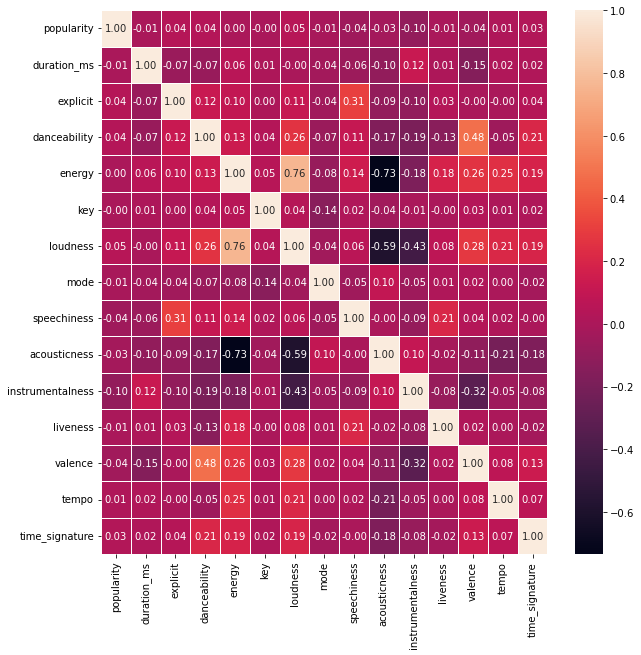

In [733]:
correlation_matrix = songs.corr()
fig, ax = plt.subplots(figsize=(10,10))
sn.heatmap(correlation_matrix, annot=True, linewidth=1, fmt=".2f")

#### Histograms
The distribution of popularity among all tracks in the dataset appears to follow either a bimodal or edge peak distribution. Since it does not have a normal distribution, normalizing this data could be helpful.

--- Prepping data for histograms ---
Num Songs >= 12 min: 301
Dropping 301 instances


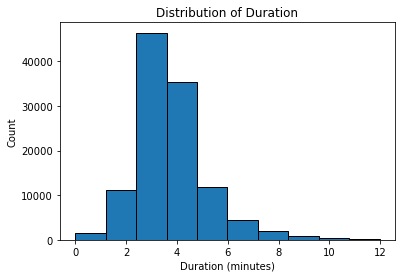

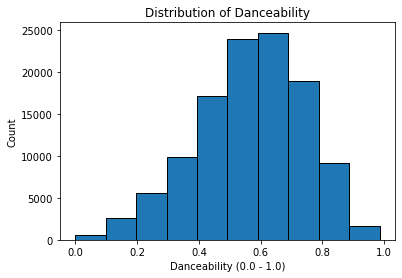

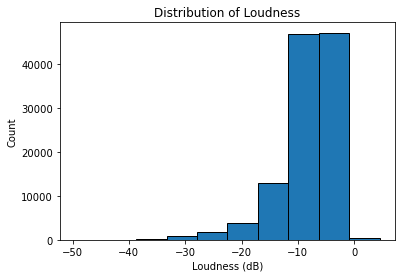

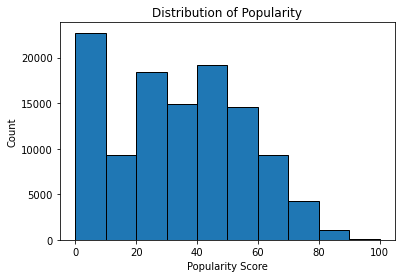

In [734]:
# data preparation
print("--- Prepping data for histograms ---")
duration_ms = songs["duration_ms"]
danceability = songs["danceability"]
loudness = songs["loudness"]
instrumentalness = songs["instrumentalness"]
popularity = songs["popularity"]

# convert song length in ms to minutes
duration_minutes = [(ms / 1000) / 60 for ms in duration_ms]
# drop all songs 12 mins or longer to clean up histogram
count = 0
for time in duration_minutes:
    if time >= 12:
        count = count + 1
print("Num Songs >= 12 min:", count)
print("Dropping", count, "instances")
# drop last 301 songs
duration_minutes = sorted(duration_minutes)
duration_minutes = duration_minutes[:(((len(duration_minutes)) - 1) - 301)]

# generate histograms
plot_utils.make_histogram(duration_minutes, "Distribution of Duration", "Duration (minutes)", "Count")
plot_utils.make_histogram(danceability, "Distribution of Danceability", "Danceability (0.0 - 1.0)", "Count")
plot_utils.make_histogram(loudness, "Distribution of Loudness", "Loudness (dB)", "Count")
plot_utils.make_histogram(popularity, "Distribution of Popularity", "Popularity Score", "Count")

#### Bar Charts
Investigating most popular genres and artists. It is useful to note that popularity is calculated using a combination of number of listens and number of recent listens, so more niche genres or artists will likely have lower popularity scores.


--- Prepping data for bar charts ---
114 different genres
values ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-r

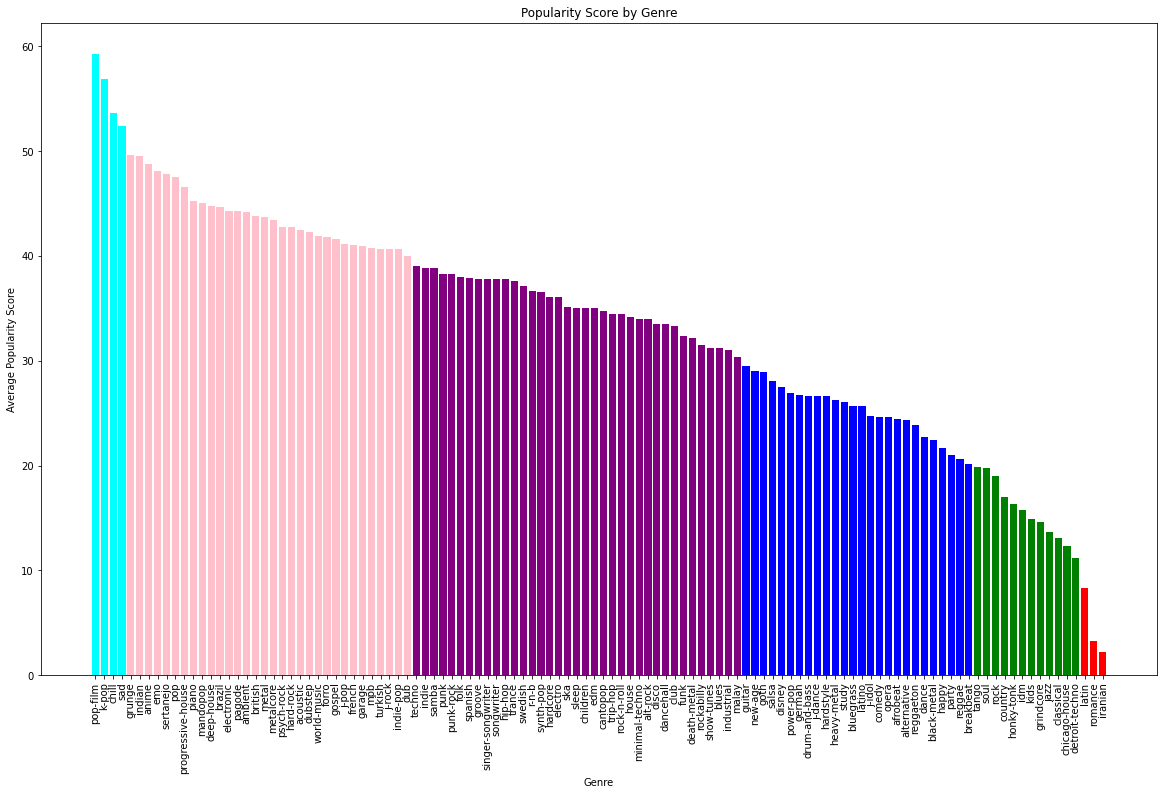

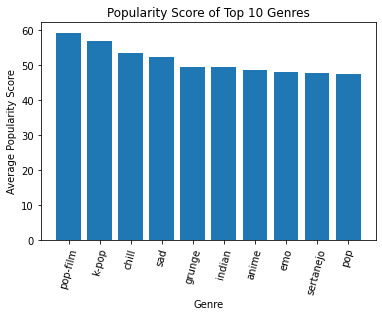

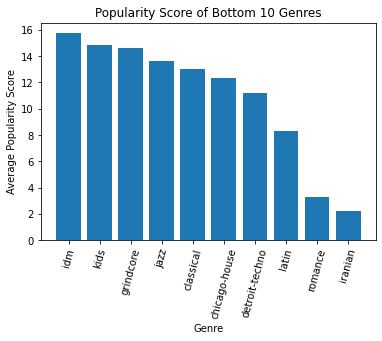

In [735]:
# popularities by genre
# data preparation
print("\n--- Prepping data for bar charts ---")
genre = songs["track_genre"]
genre_values, genre_counts = utils.get_frequencies(list(genre))
print(len(genre_values), "different genres")
print("values", genre_values)
print("counts", genre_counts)

# get average popularity score for each genre
avg_popularity = [0] * len(genre_values)
# sum popularity scores across all instances by genre
for idx, row in songs.iterrows():
    genre_index = genre_values.index(row["track_genre"])
    avg_popularity[genre_index] += row["popularity"]
# divide each sum to get average
for i, popularity_score in enumerate(avg_popularity):
    avg_popularity[i] = popularity_score / genre_counts[i]

print("Average popularities:", avg_popularity, end="\n\n")

# find top 10 most popular genres
genre_popularity = list(zip(genre_values, avg_popularity))
genre_popularity.sort(reverse=True, key=lambda x: x[1])
# unzip genre_popularity into parallel lists of genre and popularity
# for top 10 and bottom 10 most/least popular genres
top_10 = genre_popularity[:10]
top_10 = [[genre for genre, _ in top_10], [popularity for _, popularity in top_10]]
bottom_10 = genre_popularity[len(genre_popularity)-10:]
bottom_10 = [[genre for genre, _ in bottom_10], [popularity for _, popularity in bottom_10]]
genre_popularity = [[genre for genre, _ in genre_popularity], [popularity for _, popularity in genre_popularity]]

# set colors for graph of popularities by genre
colors = []
for popularity in genre_popularity[1]:
    if popularity >= 50:
        colors.append("cyan")
    elif popularity >= 40:
        colors.append("pink")
    elif popularity >= 30:
        colors.append("purple")
    elif popularity >= 20:
        colors.append("blue")
    elif popularity >= 10:
        colors.append("green")
    else:
        colors.append("red")

# generate bar charts
plot_utils.make_bar_chart(genre_popularity[0], genre_popularity[1], "Popularity Score by Genre", \
                          "Genre", "Average Popularity Score", bar_labels=genre_popularity[0], \
                          rotation=90, figsize=(20,12), color=colors)
# TODO make key for bar chart with color coded popularities
plot_utils.make_bar_chart(top_10[0], top_10[1], "Popularity Score of Top 10 Genres", "Genre", \
                          "Average Popularity Score", bar_labels=top_10[0], rotation=75)
plot_utils.make_bar_chart(bottom_10[0], bottom_10[1], "Popularity Score of Bottom 10 Genres", "Genre", \
                          "Average Popularity Score", bar_labels=bottom_10[0], rotation=75)

In [739]:
# popularities by artist
# data preparation
print("\n--- Prepping data for bar charts ---")
artist = songs["artists"]
# artist_values, artist_counts = utils.get_frequencies(list(artist))
# print(len(artist_values), "different artists")
# print("values", artist_values)
# print("counts", artist_counts)

# get top 50 artists
# TODO also look at how prolific each artist in top 50 is (maybe cut out artists that don't have more than like 20 songs, just to keep it more consistent with averages)


--- Prepping data for bar charts ---
0                    Gen Hoshino
1                   Ben Woodward
2         Ingrid Michaelson;ZAYN
3                   Kina Grannis
4               Chord Overstreet
                   ...          
113995             Rainy Lullaby
113996             Rainy Lullaby
113997             Cesária Evora
113998          Michael W. Smith
113999             Cesária Evora
Name: artists, Length: 114000, dtype: object


#### Scatterplots

In [737]:
# generate scatterplots


## Train/Test Set Building
Using stratified k-fold cross validation (with k=10).

In [738]:
y = np.array(songs.pop("popularity"))
X = np.array(songs)

## Regressor Initialization
Comparing the performance of the KNN regressor, SGD regressor, and decision tree regressor, with a linear regressor as a baseline.

## Regressor Evaluation
Using the following metrics:
* Accuracy and error rate
* Precision, recall, and F1 measure